# Flow Matching Visualization

Diagrammatic figure showing the flow matching generative process for a single halo,
plus an animated GIF sweeping from t=1 (noise) to t=0 (data).

Convention: t=1 is pure noise, t=0 is the final sample (reverse of the ODE integration
index, which runs 0→1 internally).

In [43]:
import sys
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as FancyArrowPatch
from matplotlib.colors import LogNorm
from tqdm import tqdm
import imageio

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from train import FlowMatchingLit
from data import NormStats
from test_suite.pipeline import normalize_cutout, _denormalize_to_physical

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
import scienceplots
plt.style.use(['science','notebook'])

Device: cuda


## Load Model and Data

In [22]:
RUN_DIR = Path('/mnt/home/mlee1/ceph/fm_runs/fm_two_head')
TESTSUITE_DIR = Path('/mnt/home/mlee1/ceph/fm_testsuite')
MASS_TAG = 'mass_threshold_1p000e13'
SNAP = 'snap_090'

# ── Model ───────────────────────────────────────────────────────────────────
ckpt = RUN_DIR / 'checkpoints' / 'epoch075-val_loss0.2135.ckpt'
model = FlowMatchingLit.load_from_checkpoint(str(ckpt), map_location=device)
model.eval().to(device)
ns = NormStats.load(RUN_DIR / 'norm_stats.npz')
print(f'Model loaded from {ckpt.name}')
print(f'two_head: {ns.stars_two_head}')

# ── Halo data ────────────────────────────────────────────────────────────────
mass_dir = TESTSUITE_DIR / 'CV' / 'sim_0' / SNAP / MASS_TAG
cuts = np.load(mass_dir / 'halo_cutouts.npz')   # raw physical units
cat  = np.load(mass_dir / 'halo_catalog.npz')

fiducial_params = cat['params'][0]               # (35,) CV fiducial
halo_masses     = cat['masses']                    # (N,)

print(f'\nHalos: {cuts["condition"].shape[0]}')
print(f'Fiducial params: Ωm={fiducial_params[0]:.3f}  σ8={fiducial_params[1]:.3f}')

# Largest halo
idx = int(np.argmax(halo_masses))
print(f'Largest halo: index {idx}, mass {halo_masses[idx]:.2e} M☉')

Model loaded from epoch075-val_loss0.2135.ckpt
two_head: True

Halos: 45
Fiducial params: Ωm=0.300  σ8=0.800
Largest halo: index 0, mass 2.65e+14 M☉


In [23]:
# ── Normalize cutout + params (same pipeline as test_suite) ─────────────────
hc = {'condition': cuts['condition'][idx], 'large_scale': cuts['large_scale'][idx]}
cond_np, ls_np, params_np = normalize_cutout(hc, ns, fiducial_params)

cond_t   = torch.from_numpy(cond_np).float()[None].to(device)    # (1, 1, 128, 128)
ls_t     = torch.from_numpy(ls_np).float()[None].to(device)      # (1, 3, 128, 128)
params_t = torch.from_numpy(params_np).float()[None].to(device)  # (1, 35)

print(f'condition: {cond_t.shape}  large_scale: {ls_t.shape}  params: {params_t.shape}')

condition: torch.Size([1, 1, 128, 128])  large_scale: torch.Size([1, 3, 128, 128])  params: torch.Size([1, 35])


## Sample with Intermediate States

The ODE integrates from code-t=0 (noise) → code-t=1 (data).
We label it as t=1→0 in the figure (t=1 means noise, t=0 means data).

In [30]:
@torch.no_grad()
def sample_with_snapshots(fm, cond, ls, params, n_steps=150, snapshot_code_ts=None):
    """Run ODE sampling and capture intermediate states.

    snapshot_code_ts: list of code-t values (0→1) at which to record x.
    Returns dict {code_t: (B, C, H, W) cpu tensor}.
    """
    fm.model.eval()
    B = cond.shape[0]
    dev = cond.device
    dt = 1.0 / n_steps

    if snapshot_code_ts is None:
        snapshot_code_ts = np.linspace(0, 1, 31).tolist()

    snaps = {}  # code_t → tensor

    x = torch.randn(B, fm.out_channels, cond.shape[2], cond.shape[3], device=dev)
    snaps[0.0] = x.cpu().clone()

    for step in range(n_steps):
        code_t = step * dt
        t_batch = torch.full((B,), code_t, device=dev)
        inp = torch.cat([x, cond, ls], dim=1)
        v = fm.model(inp, t_batch, params)
        x = x + v * dt

        next_code_t = (step + 1) * dt
        for record_t in snapshot_code_ts:
            if record_t not in snaps and abs(next_code_t - record_t) <= dt * 0.51:
                snaps[record_t] = x.cpu().clone()

    snaps[1.0] = x.cpu().clone()
    return snaps

print('Sampling function defined')

Sampling function defined


In [31]:
# Use a fixed seed for reproducibility
torch.manual_seed(42)

print('Running ODE sampling with 150 steps (capturing all frames for GIF)...')
gif_code_ts = np.linspace(0.0, 1.0, 41).tolist()  # 41 frames

snaps = sample_with_snapshots(
    model.fm, cond_t, ls_t, params_t,
    n_steps=150,
    snapshot_code_ts=gif_code_ts,
)
print(f'Captured {len(snaps)} snapshots at code-t values: {sorted(snaps.keys())[:5]}...{sorted(snaps.keys())[-3:]}')

Running ODE sampling with 150 steps (capturing all frames for GIF)...
Captured 41 snapshots at code-t values: [0.0, 0.025, 0.05, 0.07500000000000001, 0.1]...[0.9500000000000001, 0.9750000000000001, 1.0]


## Helper: Denormalize to Physical Space

In [32]:
def to_phys(snap_tensor):
    """(1, C, H, W) normalized tensor → (3, H, W) physical [DM, Gas, Stars]."""
    out = _denormalize_to_physical(snap_tensor.float().numpy(), ns)  # (1,3,H,W)
    return out[0]  # (3, H, W)

# Also convert the DMO condition for display
cond_phys = 10.0 ** (cond_np[0] * ns.cond_std + ns.cond_mean) - 1.0  # (128,128)
print('Denormalization function ready')

Denormalization function ready


## Load Truth Fields and Two-Head Helpers

Extract the true hydro patch for the same halo, and define helpers to expose the
raw two-head channels (occupancy, conditional density) before they are combined.


In [36]:
from test_suite.pipeline import extract_periodic_cutout

# ── Load truth maps (full 1024×1024 physical hydro projection) ───────────────
BOX_SIZE = 50.0   # Mpc/h
NPIX     = 1024
PATCH_PIX = 128

full_maps = np.load(
    TESTSUITE_DIR / 'CV' / 'sim_0' / SNAP / 'full_maps.npz'
)
truth_full = full_maps['truth_maps']  # (3, 1024, 1024) physical units [DM, Gas, Stars]

# Pixel center of the chosen halo (same calculation as extract_halo_cutouts)
pixels_per_mpc = NPIX / BOX_SIZE
halo_pos       = cat['centers'][idx]          # (x, y) in Mpc/h
cx = int(halo_pos[0] * pixels_per_mpc) % NPIX
cy = int(halo_pos[1] * pixels_per_mpc) % NPIX

# Extract 128×128 truth patch (channels extracted separately, then stacked)
truth_patch = np.stack([
    extract_periodic_cutout(truth_full[ch], cx, cy, PATCH_PIX)
    for ch in range(3)
])  # (3, 128, 128) physical units
print(f'Truth patch: {truth_patch.shape}  cx={cx} cy={cy}')
print(f'  DM  max={truth_patch[0].max():.2e}  Stars max={truth_patch[2].max():.2e}')

# ── Two-head helper: expose raw occupancy and density heads ──────────────────
def to_phys_two_head(snap_tensor):
    """Return dict of 2D arrays (128×128) for each two-head component at t=0.

    Keys: 'occ_prob'  — occupancy probability in [0, 1]
          'occ_gate'  — hard binary gate (threshold 0.5)
          'density'   — conditional density (physical, M☉/pixel) before masking
          'stars'     — final stars = occ_gate × density  (same as to_phys ch 2)
    """
    gen = snap_tensor.float().numpy()  # (1, 4, H, W)
    occ_raw     = gen[0, 2] * ns.stars_occ_std   + ns.stars_occ_mean   # linear prob
    density_log = gen[0, 3] * ns.stars_cond_std  + ns.stars_cond_mean  # log10(1+x)
    density_phys = 10.0 ** density_log - 1.0
    occ_gate     = (occ_raw > 0.5).astype(np.float32)
    return {
        'occ_prob':  occ_raw,
        'occ_gate':  occ_gate,
        'density':   density_phys,
        'stars':     occ_gate * density_phys,
    }

two_head_gen = to_phys_two_head(snaps[1.0])
print('\nGenerated two-head at t=0:')
print(f'  occ fraction: {two_head_gen["occ_gate"].mean():.3f}  '
      f'(truth: {(truth_patch[2] > 0).mean():.3f})')
print(f'  stars total: {two_head_gen["stars"].sum():.3e}  '
      f'(truth: {truth_patch[2].sum():.3e})')


Truth patch: (3, 128, 128)  cx=31 cy=724
  DM  max=2.58e+12  Stars max=1.92e+11

Generated two-head at t=0:
  occ fraction: 0.263  (truth: 0.269)
  stars total: 4.292e+12  (truth: 3.852e+12)


## Static Figure: t=1 → t=0.5 → t=0

t=1 is the starting noise, t=0 is the final sample (paper convention).

/tmp/ipykernel_627057/2543420060.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_r = mpl_cm.get_cmap('RdBu_r').copy()


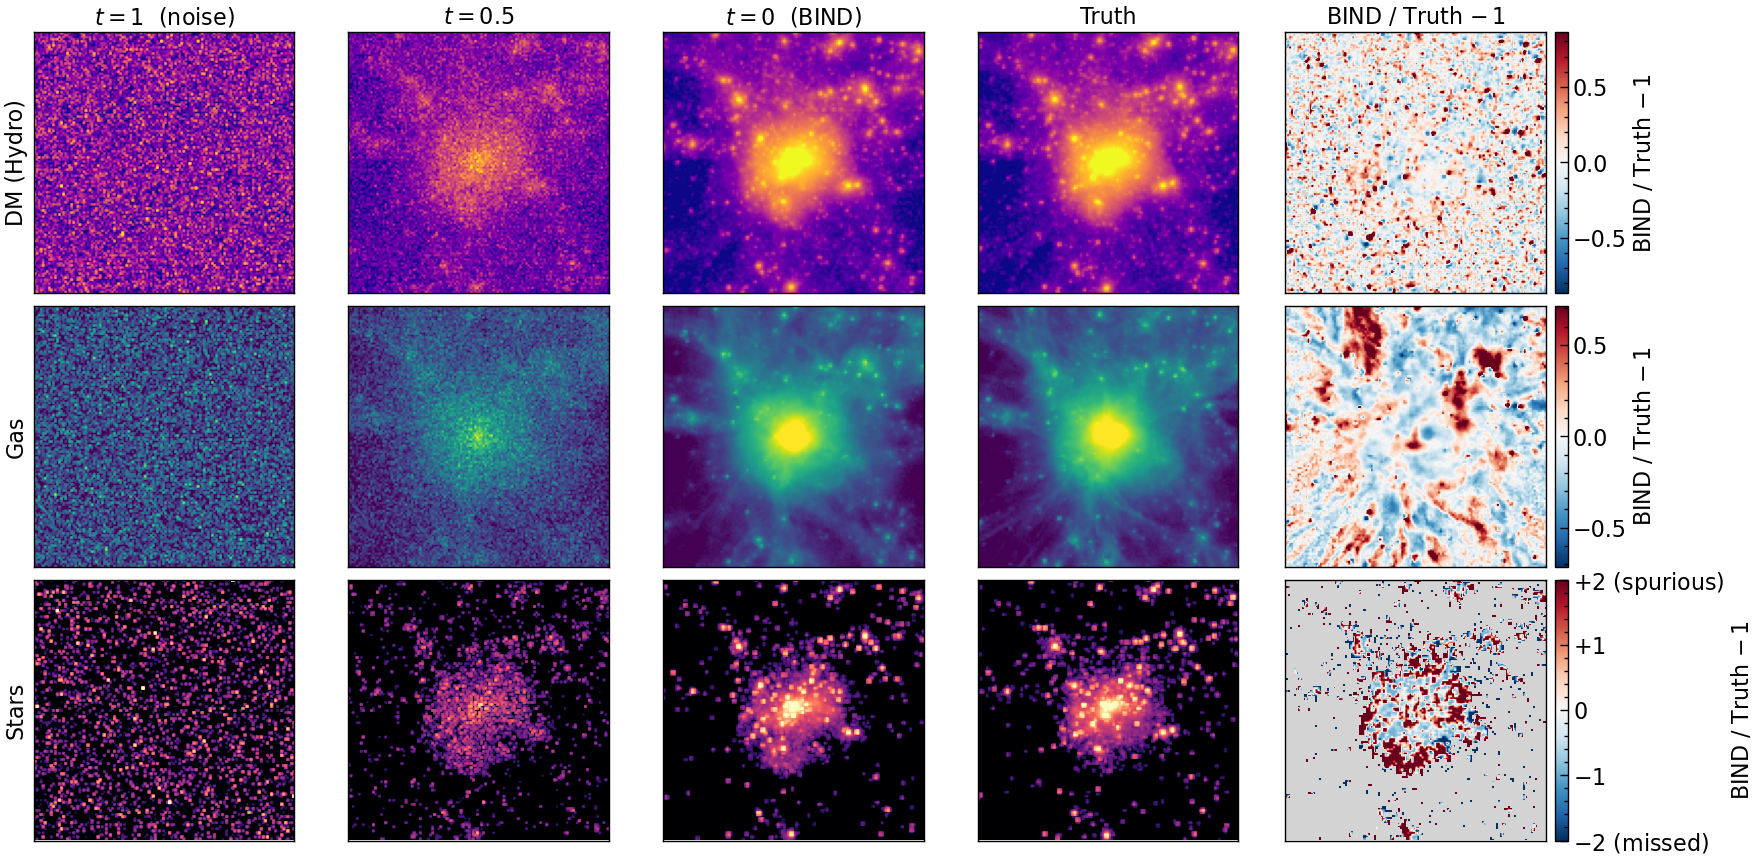

Static figure saved.


In [49]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as mpl_cm

# Figure convention: display t = 1 - code_t
# t=1 (noise)  → code_t=0.0
# t=0.5        → code_t=0.5
# t=0 (data)   → code_t=1.0

bind_phys = to_phys(snaps[1.0])

# Compute global vmin/vmax per channel from the truth patch
vmins, vmaxs = [], []
for ch in range(3):
    vals = truth_patch[ch][truth_patch[ch] > 0]
    vmins.append(float(np.percentile(vals, 5))  if len(vals) else 1e-2)
    vmaxs.append(float(np.percentile(vals, 99)) if len(vals) else 1e4)

# Relative difference: BIND / truth - 1
# DM & Gas: NaN where truth is below the 5th-pct floor
# Stars (ch 2): encode sparsity explicitly
#   both nonzero  → clip(BIND/truth-1, -2, 2)
#   truth>0, bind=0 (missed)   → -2  (deep blue)
#   truth=0, bind>0 (spurious) → +2  (deep red)
#   both zero                  → NaN (masked, shown as light gray)
ratio_patch = np.full_like(truth_patch, np.nan)
for ch in range(3):
    t = truth_patch[ch]
    b = bind_phys[ch]
    if ch < 2:
        valid = t > vmins[ch] * 0.5
        ratio_patch[ch] = np.where(
            valid,
            b / np.where(valid, t, 1.0) - 1.0,
            np.nan,
        )
    else:
        # Stars: categorical + continuous
        both  = (t > 0) & (b > 0)
        t_only = (t > 0) & (b <= 0)   # missed
        b_only = (t <= 0) & (b > 0)   # spurious
        r = np.full_like(t, np.nan)
        r = np.where(both,   np.clip(b / np.where(both, t, 1.0) - 1.0, -2.0, 2.0), r)
        r = np.where(t_only, -2.0, r)
        r = np.where(b_only, +2.0, r)
        ratio_patch[ch] = r

display_panels = {
    r'$t = 1$  (noise)':      to_phys(snaps[0.0]),
    r'$t = 0.5$':             to_phys(snaps[0.5]),
    r'$t = 0$  (BIND)':       bind_phys,
    r'Truth':                  truth_patch,
    r'BIND / Truth $-\,1$':   ratio_patch,
}
ch_labels  = ['DM (Hydro)', 'Gas', 'Stars']
cmaps      = ['plasma', 'viridis', 'magma']

n_cols = len(display_panels)
n_rows = 3  # channels

fig = plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))
gs  = gridspec.GridSpec(n_rows, n_cols, hspace=0.05, wspace=0.08)

for col, (panel_label, phys) in enumerate(display_panels.items()):
    is_ratio = (col == n_cols - 1)
    for row, ch in enumerate(range(3)):
        ax = fig.add_subplot(gs[row, col])
        if is_ratio:
            ratio_ch = phys[ch]
            if ch < 2:
                finite_vals = ratio_ch[np.isfinite(ratio_ch)]
                abs_max = float(np.percentile(np.abs(finite_vals), 98)) if len(finite_vals) else 1.0
            else:
                abs_max = 2.0   # fixed scale so ±2 sentinels sit at colormap extremes
            norm_r = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
            cmap_r = mpl_cm.get_cmap('RdBu_r').copy()
            cmap_r.set_bad(color='lightgray')
            im = ax.imshow(ratio_ch, origin='lower', cmap=cmap_r, norm=norm_r)
        else:
            img = np.clip(phys[ch], vmins[ch] * 0.1, None)
            img = np.where(img <= 0, vmins[ch] * 0.1, img)
            im = ax.imshow(img, origin='lower', cmap=cmaps[ch],
                           norm=LogNorm(vmin=vmins[ch], vmax=vmaxs[ch]))
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(panel_label, pad=6)
        if col == 0:
            ax.set_ylabel(ch_labels[ch])
        if col == n_cols - 1:
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            if is_ratio:
                cb.set_label(r'BIND / Truth $-\,1$')
                if ch == 2:
                    cb.set_ticks([-2, -1, 0, 1, 2])
                    cb.set_ticklabels([r'$-2$ (missed)', r'$-1$', r'$0$',
                                       r'$+1$', r'$+2$ (spurious)'])
            else:
                cb.set_label(r'$h^{-1}\,M_\odot$')


out_dir = Path('/mnt/home/mlee1/vdm_bind2/paper_figures')
plt.savefig(out_dir / 'flow_matching_diagram.pdf', bbox_inches='tight', dpi=150)
plt.savefig(out_dir / 'flow_matching_diagram.png', bbox_inches='tight', dpi=150)
plt.show()
print('Static figure saved.')


## Two-Head Stars Decomposition: Generated vs Truth

The model predicts stars via two heads: an **occupancy** channel (binary gate on
which pixels contain stars) and a **conditional density** channel (the mass per
occupied pixel). The final stars map is their product. Here we visualise each
component side-by-side with the truth.


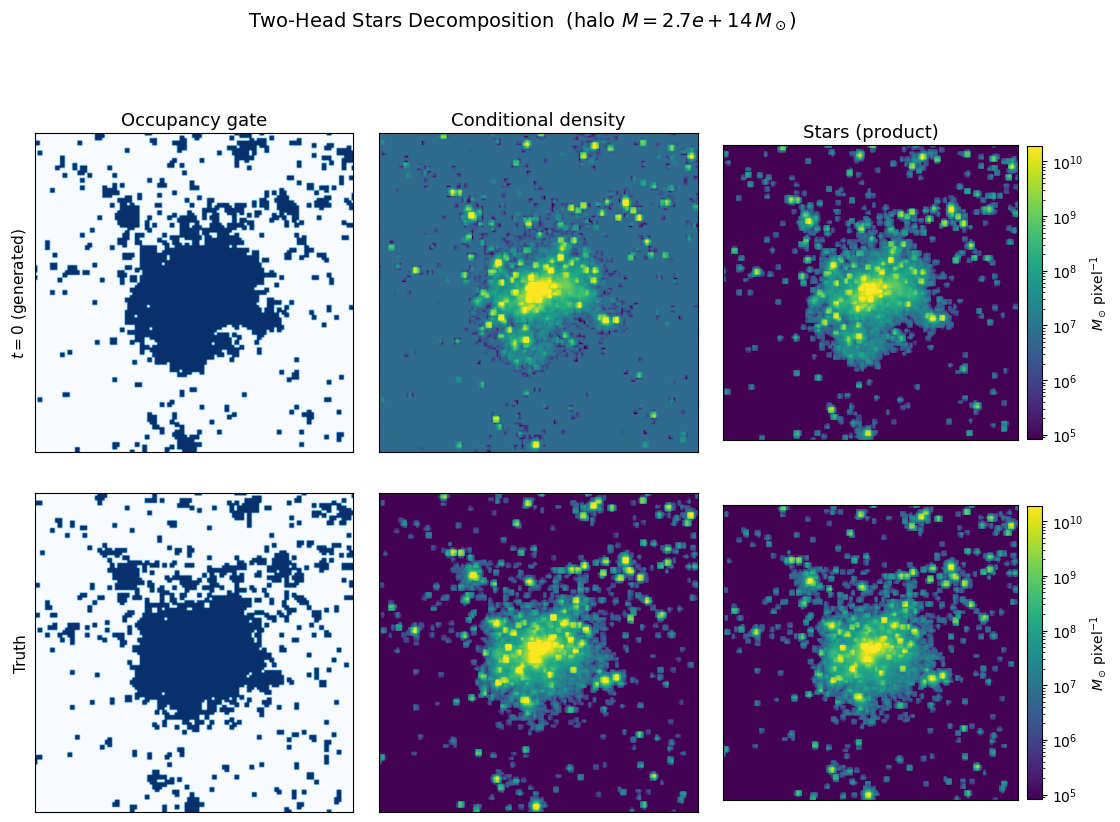

Two-head decomposition figure saved.


In [38]:
from matplotlib.colors import Normalize

# ── Truth two-head decomposition ─────────────────────────────────────────────
truth_stars  = truth_patch[2]                          # (128,128) physical M☉/pix
truth_occ    = (truth_stars > 0).astype(np.float32)    # binary occupancy
truth_density = np.where(truth_occ > 0, truth_stars, 0.0)  # conditional density

# ── Layout: 2 rows (Generated / Truth) × 3 cols (occ | density | stars) ─────
col_titles = ['Occupancy gate', 'Conditional density', 'Stars (product)']
row_labels = [r'$t=0$ (generated)', 'Truth']

# Row data: each entry is a 2D array (128×128)
rows_data = [
    [two_head_gen['occ_gate'],  two_head_gen['density'],  two_head_gen['stars']],
    [truth_occ,                  truth_density,             truth_stars],
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
fig.subplots_adjust(hspace=0.08, wspace=0.08)

# Shared colour scale per column (computed from truth + gen combined)
for col_idx in range(3):
    all_vals = np.concatenate([rows_data[0][col_idx].ravel(),
                                rows_data[1][col_idx].ravel()])

    if col_idx == 0:
        # Occupancy: linear [0, 1]
        norm = Normalize(vmin=0, vmax=1)
        cmap = 'Blues'
        cbar_label = 'Occupancy'
    else:
        # Density / Stars: log scale
        pos_vals = all_vals[all_vals > 0]
        vmin_c = float(np.percentile(pos_vals, 2))  if len(pos_vals) else 1e-2
        vmax_c = float(np.percentile(pos_vals, 99)) if len(pos_vals) else 1e4
        norm = LogNorm(vmin=vmin_c, vmax=vmax_c)
        cmap = 'viridis'
        cbar_label = r'$M_\odot\,\mathrm{pixel}^{-1}$'

    for row_idx in range(2):
        ax = axes[row_idx, col_idx]
        data = rows_data[row_idx][col_idx]
        if col_idx == 0:
            im = ax.imshow(data, origin='lower', cmap=cmap, norm=norm)
        else:
            disp = np.where(data > 0, data, norm.vmin * 0.1)
            im = ax.imshow(disp, origin='lower', cmap=cmap, norm=norm)
        ax.set_xticks([])
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=13, pad=6)
        if col_idx == 0:
            ax.set_ylabel(row_labels[row_idx], fontsize=11)
        if col_idx == 2:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03, label=cbar_label)

plt.suptitle(
    'Two-Head Stars Decomposition  '
    fr'(halo $M = {halo_masses[idx]:.1e}\,M_\odot$)',
    fontsize=14, y=1.01,
)

plt.savefig(out_dir / 'two_head_decomposition.pdf', bbox_inches='tight', dpi=150)
plt.savefig(out_dir / 'two_head_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()
print('Two-head decomposition figure saved.')


## Paper Figure: Flow Matching Overview (Flowchart + Evolution + Two-Head)

Three-panel publication figure:

* **(a)** Mathematical flowchart — training interpolant, ODE inference, model inputs/outputs
* **(b)** Field evolution — all three channels at t = 1, 0.5, 0 compared with the truth
* **(c)** Two-head stars decomposition — occupancy gate × conditional density = stars, generated vs truth


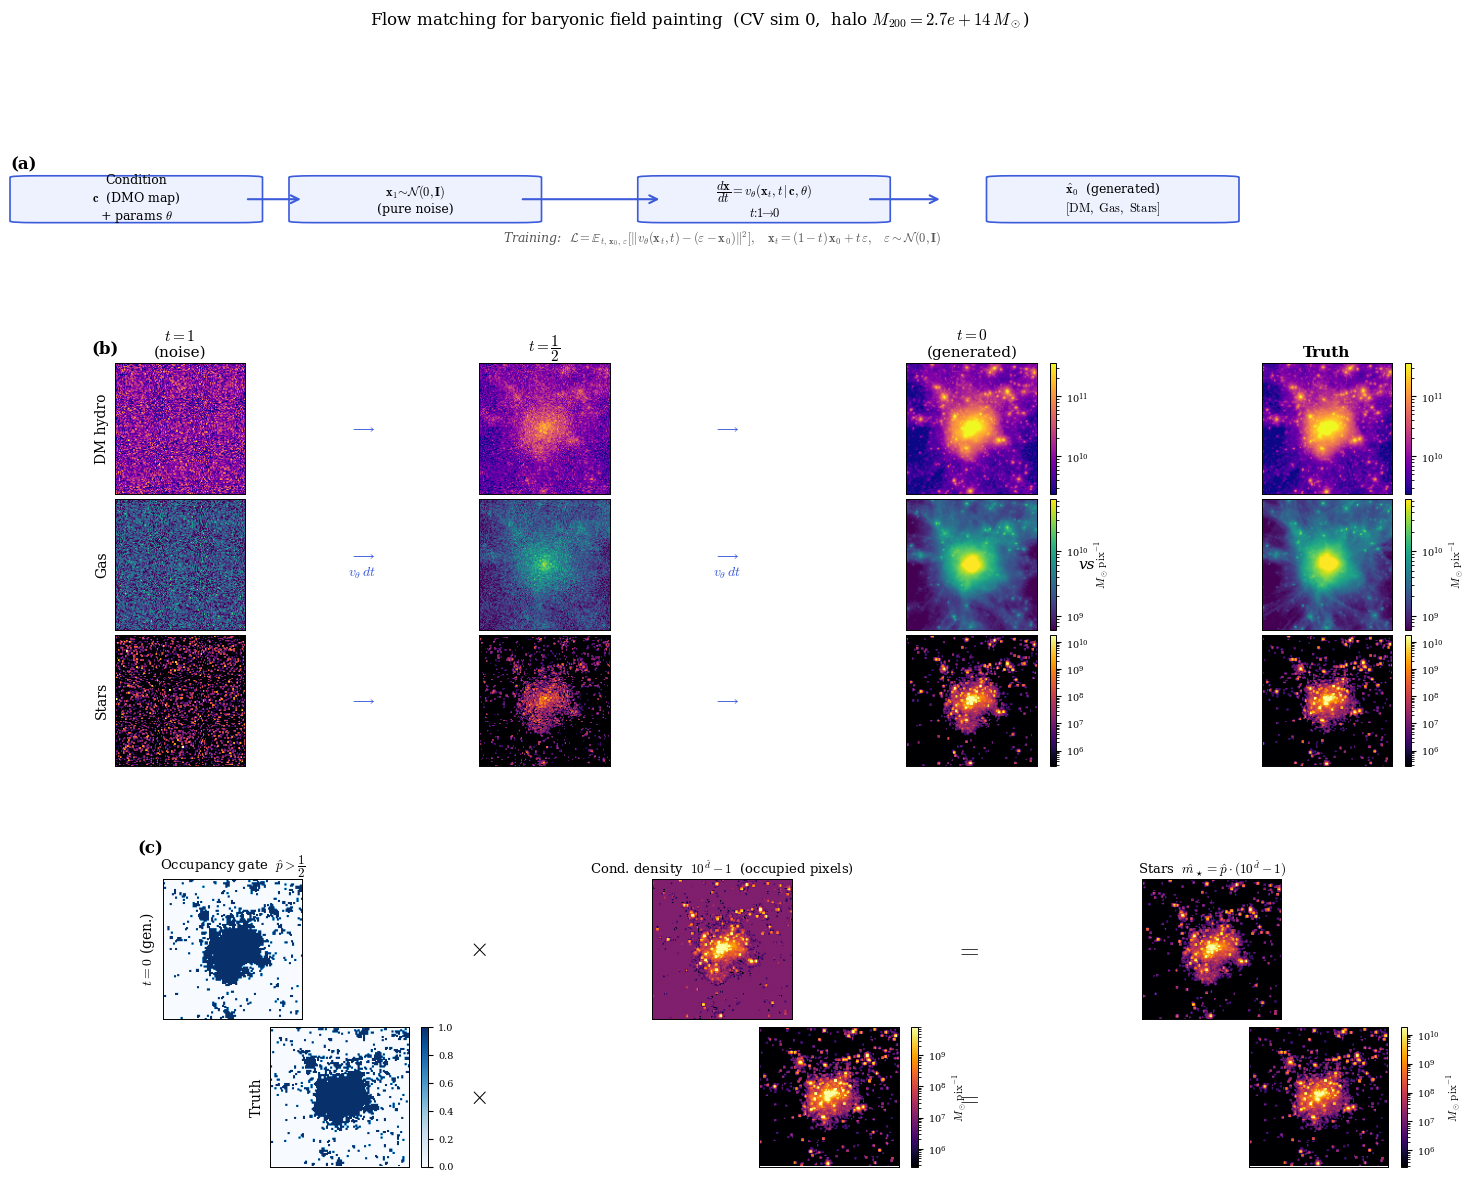

Paper figure saved.


In [42]:
import matplotlib
from matplotlib.patches import FancyBboxPatch

# ── Colour scales (all anchored to truth) ────────────────────────────────────
CH_CMAPS = ['plasma', 'viridis', 'inferno']   # DM, Gas, Stars
CH_LBLS  = ['DM hydro', 'Gas', 'Stars']

# Two-head density/stars: shared scale across generated and truth
_all_dens = np.concatenate([
    two_head_gen['density'][two_head_gen['density'] > 0],
    truth_density[truth_density > 0],
])
_vmin_d = float(np.percentile(_all_dens, 2))  if len(_all_dens) else 1e-2
_vmax_d = float(np.percentile(_all_dens, 99)) if len(_all_dens) else 1e4

# Brand colour used for flowchart accents
_EDGE = '#3B5BDB'
_BG   = '#EEF2FF'

with matplotlib.rc_context({
    'font.family':     'serif',
    'mathtext.fontset': 'cm',
    'axes.linewidth':  0.7,
    'font.size':       10,
}):
    fig = plt.figure(figsize=(18, 13), facecolor='white')
    outer = gridspec.GridSpec(3, 1, figure=fig,
                              height_ratios=[0.22, 1.05, 0.75],
                              hspace=0.44)

    # ── (a) Mathematical flowchart ────────────────────────────────────────────
    ax_h = fig.add_subplot(outer[0])
    ax_h.set_axis_off()
    ax_h.set_xlim(0, 1); ax_h.set_ylim(0, 1)
    ax_h.text(-0.01, 1.12, '(a)', transform=ax_h.transAxes,
              fontsize=12, fontweight='bold', va='top')

    bw, bh = 0.145, 0.52
    _boxes = [
        (0.08,  0.60,
         'Condition\n'
         r'$\mathbf{c}$' + '  (DMO map)\n+ params '
         r'$\theta$'),
        (0.28,  0.60,
         r'$\mathbf{x}_1 \!\sim\! \mathcal{N}(\mathbf{0},\mathbf{I})$'
         '\n(pure noise)'),
        (0.53,  0.60,
         r'$\dfrac{d\mathbf{x}}{dt} = v_\theta(\mathbf{x}_t, t \,|\, \mathbf{c}, \theta)$'
         '\n' r'$t \colon 1 \!\to\! 0$'),
        (0.78,  0.60,
         r'$\hat{\mathbf{x}}_0$' + '  (generated)\n'
         r'$[\mathrm{DM},\ \mathrm{Gas},\ \mathrm{Stars}]$'),
    ]
    for bx, by, txt in _boxes:
        ax_h.add_patch(FancyBboxPatch(
            (bx - bw / 2, by - bh / 2), bw, bh,
            boxstyle='round,pad=0.018',
            facecolor=_BG, edgecolor=_EDGE, linewidth=1.2,
            transform=ax_h.transAxes, zorder=2, clip_on=False,
        ))
        ax_h.text(bx, by, txt, ha='center', va='center', fontsize=9,
                  transform=ax_h.transAxes, zorder=3, multialignment='center')

    for _x0, _x1 in [(0.158, 0.200), (0.355, 0.457), (0.604, 0.658)]:
        ax_h.annotate('', xy=(_x1, 0.60), xytext=(_x0, 0.60),
                      xycoords='axes fraction', textcoords='axes fraction',
                      arrowprops=dict(arrowstyle='->', color=_EDGE,
                                      lw=1.5, mutation_scale=14), zorder=4)

    ax_h.text(
        0.50, 0.03,
        r'Training:  '
        r'$\mathcal{L} = \mathbb{E}_{t,\,\mathbf{x}_0,\,{\varepsilon}}'
        r'[\|v_\theta(\mathbf{x}_t, t) - ({\varepsilon} - \mathbf{x}_0)\|^2]$'
        r'$,\quad \mathbf{x}_t = (1-t)\,\mathbf{x}_0 + t\,{\varepsilon},'
        r'\quad {\varepsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$',
        ha='center', va='bottom', fontsize=9,
        style='italic', color='#555', transform=ax_h.transAxes,
    )

    # ── (b) Field evolution: noise → t=0.5 → generated  |  truth ─────────────
    # col layout: [t=1 | → | t=0.5 | → | t=0 gen | vs | truth]
    mid = gridspec.GridSpecFromSubplotSpec(
        3, 7, subplot_spec=outer[1],
        hspace=0.04, wspace=0.06,
        width_ratios=[1, 0.10, 1, 0.10, 1, 0.07, 1],
    )
    _traj = [
        (0, r'$t=1$'           + '\n(noise)',      to_phys(snaps[0.0])),
        (2, r'$t=\dfrac{1}{2}$',                   to_phys(snaps[0.5])),
        (4, r'$t=0$'           + '\n(generated)',  to_phys(snaps[1.0])),
    ]
    for gc, ttl, phys in _traj:
        for ri, ch_i in enumerate(range(3)):
            ax = fig.add_subplot(mid[ri, gc])
            img = np.clip(phys[ch_i], vmins[ch_i] * 0.1, None)
            img = np.where(img <= 0, vmins[ch_i] * 0.1, img)
            im = ax.imshow(img, origin='lower', cmap=CH_CMAPS[ch_i],
                           norm=LogNorm(vmin=vmins[ch_i], vmax=vmaxs[ch_i]))
            ax.set_xticks([]); ax.set_yticks([])
            if ri == 0:
                ax.set_title(ttl, fontsize=11, pad=5)
            if gc == 0:
                ax.set_ylabel(CH_LBLS[ch_i], fontsize=10)
                if ri == 0:
                    ax.text(-0.18, 1.18, '(b)', transform=ax.transAxes,
                            fontsize=12, fontweight='bold', va='top')
            # Colorbars on the last trajectory column only
            if gc == 4:
                cb = plt.colorbar(im, ax=ax, fraction=0.048, pad=0.04)
                cb.set_label(r'$M_\odot\,\mathrm{pix}^{-1}$' if ri == 1 else '',
                             fontsize=8)
                cb.ax.tick_params(labelsize=7)

    # Arrow / ODE-label columns
    for ac in [1, 3]:
        for ri in range(3):
            ax_a = fig.add_subplot(mid[ri, ac])
            ax_a.set_axis_off()
            lbl = (r'$\longrightarrow$' + '\n' + r'$v_\theta\,dt$'
                   if ri == 1 else r'$\longrightarrow$')
            ax_a.text(0.5, 0.5, lbl, ha='center', va='center',
                      fontsize=10, color=_EDGE, transform=ax_a.transAxes)

    # "vs" separator before truth
    for ri in range(3):
        ax_vs = fig.add_subplot(mid[ri, 5])
        ax_vs.set_axis_off()
        if ri == 1:
            ax_vs.text(0.5, 0.5, 'vs', ha='center', va='center',
                       fontsize=11, style='italic', transform=ax_vs.transAxes)

    # Truth column
    for ri, ch_i in enumerate(range(3)):
        ax = fig.add_subplot(mid[ri, 6])
        img = np.clip(truth_patch[ch_i], vmins[ch_i] * 0.1, None)
        img = np.where(img <= 0, vmins[ch_i] * 0.1, img)
        im = ax.imshow(img, origin='lower', cmap=CH_CMAPS[ch_i],
                       norm=LogNorm(vmin=vmins[ch_i], vmax=vmaxs[ch_i]))
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title('Truth', fontsize=11, pad=5, fontweight='bold')
        cb = plt.colorbar(im, ax=ax, fraction=0.048, pad=0.04)
        cb.set_label(r'$M_\odot\,\mathrm{pix}^{-1}$' if ri == 1 else '',
                     fontsize=8)
        cb.ax.tick_params(labelsize=7)

    # ── (c) Two-head stars decomposition ─────────────────────────────────────
    # rows: generated | truth
    # cols: [occ | × | cond. density | = | stars]
    bot = gridspec.GridSpecFromSubplotSpec(
        2, 5, subplot_spec=outer[2],
        hspace=0.06, wspace=0.06,
        width_ratios=[1, 0.10, 1, 0.10, 1],
    )
    _norm_occ_b  = matplotlib.colors.Normalize(vmin=0, vmax=1)
    _norm_dens_b = LogNorm(vmin=_vmin_d, vmax=_vmax_d)
    _norm_star_b = LogNorm(vmin=vmins[2], vmax=vmaxs[2])

    _bot_rows = [
        (two_head_gen['occ_gate'], two_head_gen['density'], two_head_gen['stars'],
         r'$t=0$ (gen.)'),
        (truth_occ,                truth_density,           truth_patch[2],
         'Truth'),
    ]
    _bot_titles = [
        r'Occupancy gate  $\hat{p} > \dfrac{1}{2}$',
        r'Cond. density  $10^{\hat{d}}-1$  (occupied pixels)',
        r'Stars  $\hat{m}_\star = \hat{p} \cdot (10^{\hat{d}}-1)$',
    ]
    _bot_specs = [
        ('Blues',   _norm_occ_b,  None,     _bot_titles[0]),
        ('inferno', _norm_dens_b, _vmin_d,  _bot_titles[1]),
        ('inferno', _norm_star_b, vmins[2], _bot_titles[2]),
    ]

    for ri, (occ_d, dens_d, stars_d, row_lbl) in enumerate(_bot_rows):
        for ci, (arr, (cmap_b, norm_b, clip_min, ctitle)) in enumerate(
            zip([occ_d, dens_d, stars_d], _bot_specs)
        ):
            gc = ci * 2  # image columns: 0, 2, 4
            ax = fig.add_subplot(bot[ri, gc])
            if clip_min is None:
                im = ax.imshow(arr, origin='lower', cmap=cmap_b, norm=norm_b)
            else:
                disp = np.where(arr > 0, arr, clip_min * 0.1)
                im = ax.imshow(disp, origin='lower', cmap=cmap_b, norm=norm_b)
            ax.set_xticks([]); ax.set_yticks([])
            if ri == 0:
                ax.set_title(ctitle, fontsize=9.5, pad=4)
                if ci == 0:
                    ax.text(-0.18, 1.28, '(c)', transform=ax.transAxes,
                            fontsize=12, fontweight='bold', va='top')
            if ci == 0:
                ax.set_ylabel(row_lbl, fontsize=10)
            if ri == 1:
                cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
                if ci >= 1:
                    cb.set_label(r'$M_\odot\,\mathrm{pix}^{-1}$', fontsize=8)
                cb.ax.tick_params(labelsize=7)

        # Operator symbols (× and =) in narrow columns 1 and 3
        for sym_col, sym_txt in [(1, r'$\times$'), (3, r'$=$')]:
            ax_sym = fig.add_subplot(bot[ri, sym_col])
            ax_sym.set_axis_off()
            ax_sym.text(0.5, 0.5, sym_txt, ha='center', va='center',
                        fontsize=18, transform=ax_sym.transAxes)

    fig.suptitle(
        r'Flow matching for baryonic field painting'
        fr'  (CV sim 0,  halo $M_{{200}} = {halo_masses[idx]:.1e}\,M_\odot$)',
        fontsize=12, y=1.00,
    )

    plt.savefig(out_dir / 'flow_matching_paper_figure.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(out_dir / 'flow_matching_paper_figure.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Paper figure saved.')


## GIF: Full Sampling Trajectory

41 frames sweeping the display label from t=1 down to t=0.

In [39]:
def make_gif_frame(phys_3ch, display_t, vmins, vmaxs, cmaps):
    """Return an (H, W, 3) uint8 RGB array for one GIF frame (all 3 channels side-by-side)."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ch, (ax, cmap) in enumerate(zip(axes, cmaps)):
        img = np.clip(phys_3ch[ch], vmins[ch] * 0.1, None)
        img = np.where(img <= 0, vmins[ch] * 0.1, img)
        im = ax.imshow(img, origin='lower', cmap=cmap,
                       norm=LogNorm(vmin=vmins[ch], vmax=vmaxs[ch]))
        ax.set_title(ch_labels[ch], fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

    fig.suptitle(f'Flow Matching  —  $t = {display_t:.2f}$', fontsize=14, y=1.01)
    plt.tight_layout()

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    return buf


print('Building GIF frames...')
frames = []
# gif_code_ts runs 0→1; display_t = 1 - code_t (1 = noise, 0 = data)
for code_t in tqdm(sorted(snaps.keys())):
    phys = to_phys(snaps[code_t])
    display_t = 1.0 - code_t
    frame = make_gif_frame(phys, display_t, vmins, vmaxs, cmaps)
    frames.append(frame)

gif_path = out_dir / 'flow_matching_sampling.gif'
imageio.mimsave(str(gif_path), frames, duration=0.12, loop=0)
print(f'GIF saved: {gif_path}  ({len(frames)} frames)')

Building GIF frames...


100%|██████████| 41/41 [00:18<00:00,  2.27it/s]


GIF saved: /mnt/home/mlee1/vdm_bind2/paper_figures/flow_matching_sampling.gif  (41 frames)
